In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Load data
df = pd.read_csv(r"C:\Users\hp\Pictures\brent-change-point\brent-change-point\data\raw\BrentOilPrices.csv")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Set index
df.set_index('Date', inplace=True)

print(df.head())


C:\Users\hp\AppData\Local\Temp\ipykernel_4964\3441892249.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


            Price
Date             
1987-05-20  18.63
1987-05-21  18.45
1987-05-22  18.55
1987-05-25  18.60
1987-05-26  18.63


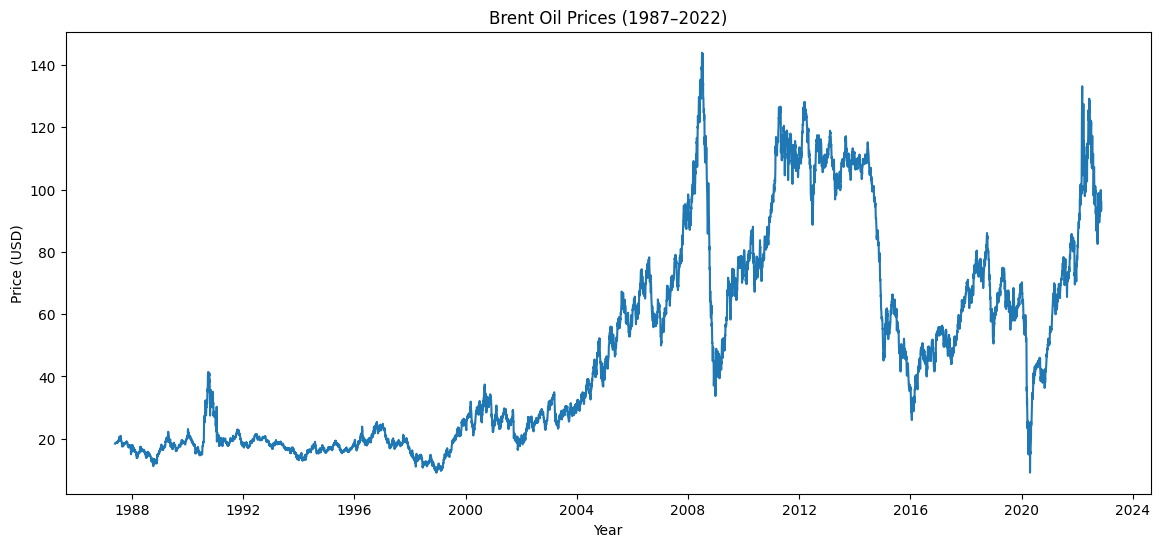

In [8]:
#Plot Raw Price Series
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Price'])
plt.title("Brent Oil Prices (1987–2022)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
import os
# Full path to save the figure
save_path = r"C:\Users\hp\Pictures\brent-change-point\brent-change-point\reports\figures\brent_oil_prices.png"
# Make sure the directory exists
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the figure
plt.savefig(save_path)
plt.show()


In [3]:
#Log Returns
df['log_price'] = np.log(df['Price'])
df['log_return'] = df['log_price'].diff()

df = df.dropna()

In [4]:
#Stationarity Test
result = adfuller(df['log_return'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -16.427113494485894
p-value: 2.4985801611428892e-29


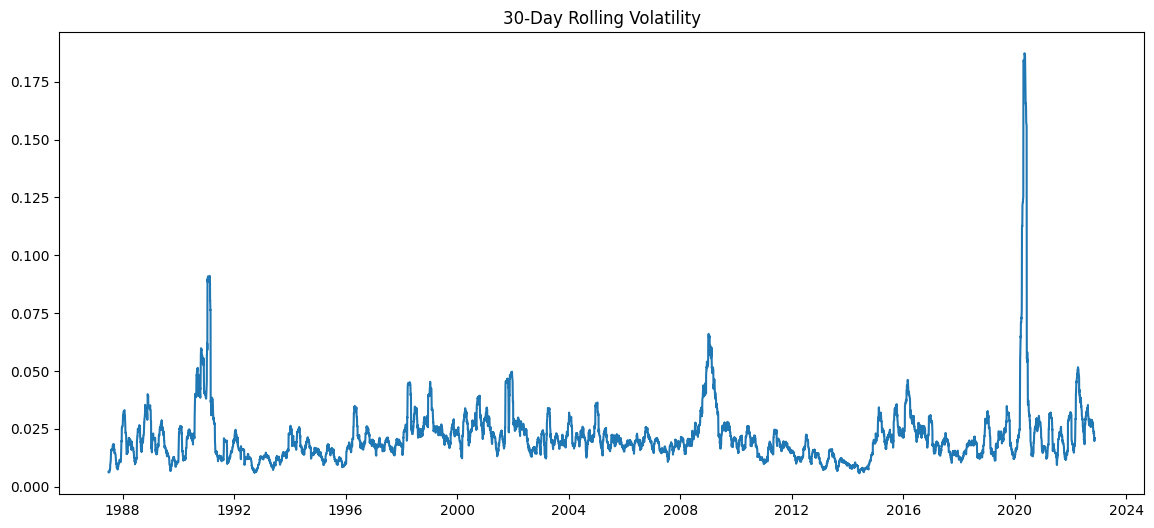

In [ ]:
#Volatility Clustering
df['rolling_vol'] = df['log_return'].rolling(30).std()

plt.figure(figsize=(14,6))
plt.plot(df.index, df['rolling_vol'])
plt.title("30-Day Rolling Volatility")
import os
# Full path to save the figure
save_path = r"C:\Users\hp\Pictures\brent-change-point\brent-change-point\reports\figures\30_Day_Rolling_Volatility.png"
# Make sure the directory exists
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the figure
plt.savefig(save_path)
plt.show()


In [17]:
# =========================
# Brent Change Point Analysis
# =========================

import sys
sys.path.append('../src')  # Include src if you have modules there

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import os

# =========================
# Configuration
# =========================
pytensor.config.cxx = ""       # Disable g++ warnings
matplotlib.use("Agg")          # Non-interactive backend for plots

# Data paths (adjust to your folder structure)
RAW_DATA_PATH = r'C:\Users\hp\Pictures\brent-change-point\brent-change-point\data\raw\BrentOilPrices.csv'
EVENTS_DATA_PATH = r'C:\Users\hp\Pictures\brent-change-point\brent-change-point\data\raw\events.csv'
PROCESSED_OIL_PATH = r'../data/processed_oil_prices.csv'
PROCESSED_EVENTS_PATH = r'../data/processed_events.csv'
START_DATE = '2020-01-01'
END_DATE = '2021-12-31'

# =========================
# Data loading and preprocessing
# =========================

def load_oil_data(path):
    df = pd.read_csv(path)
    # Auto-detect date and price columns
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    price_col = [c for c in df.columns if 'price' in c.lower()][0]
    df.rename(columns={date_col: 'date', price_col: 'price'}, inplace=True)
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)
    return df

def create_features(df):
    df['price_diff'] = df['price'].diff()
    df['price_pct_change'] = df['price'].pct_change()
    return df

def load_and_merge_events(oil_df, events_path):
    events_df = pd.read_csv(events_path)
    # Auto-detect date column
    date_col = [c for c in events_df.columns if 'date' in c.lower()][0]
    events_df.rename(columns={date_col: 'date'}, inplace=True)
    events_df['date'] = pd.to_datetime(events_df['date'])
    merged_df = oil_df.merge(events_df, on='date', how='left')
    return merged_df, events_df

def filter_time_period(df, start_date, end_date):
    mask = (df['date'] >= start_date) & (df['date'] <= end_date)
    return df.loc[mask]

# =========================
# Bayesian Change Point Detector
# =========================

class BayesianChangePointDetector:
    """Bayesian change point detection using PyMC"""

    def __init__(self, n_samples=2000, n_tune=1000, random_seed=42):
        self.n_samples = n_samples
        self.n_tune = n_tune
        self.random_seed = random_seed
        self.trace = None
        self.model = None

    def fit(self, data):
        data = np.asarray(data)
        n = len(data)
        with pm.Model() as model:
            tau = pm.DiscreteUniform("tau", lower=0, upper=n - 1)
            mu1 = pm.Normal("mu1", mu=data.mean(), sigma=data.std() * 2)
            mu2 = pm.Normal("mu2", mu=data.mean(), sigma=data.std() * 2)
            sigma = pm.HalfNormal("sigma", sigma=data.std())
            idx = np.arange(n)
            mu = pm.math.switch(tau > idx, mu1, mu2)
            pm.Normal("obs", mu=mu, sigma=sigma, observed=data)

            self.trace = pm.sample(
                draws=self.n_samples,
                tune=self.n_tune,
                chains=2,
                random_seed=self.random_seed,
                return_inferencedata=True,
                target_accept=0.9
            )
            self.model = model
        return self

    def diagnose(self):
        if self.trace is None:
            raise ValueError("Model not fitted yet")
        summary = az.summary(self.trace)
        print("\nModel Summary:")
        print(summary)
        print("\nR-hat values (should be < 1.1):")
        print(summary[["r_hat"]])
        return summary

    def plot_trace(self, filename="traceplot.png"):
        if self.trace is None:
            raise ValueError("Model not fitted yet")
        az.plot_trace(self.trace)
        plt.tight_layout()
        plt.savefig(filename)
        plt.close()
        print(f"Trace plot saved to {filename}")

    def save_trace(self, filename="brent_changepoint_trace.nc"):
        if self.trace is None:
            raise ValueError("Model not fitted yet")
        az.to_netcdf(self.trace, filename)
        print(f"Trace saved to: {filename}")

    def get_change_point_results(self, dates):
        if self.trace is None:
            raise ValueError("Model not fitted yet")
        tau_samples = self.trace.posterior["tau"].values.flatten().astype(int)
        change_point_dates = [dates[t] for t in tau_samples]
        df = pd.DataFrame({"tau": tau_samples, "date": change_point_dates})
        mode_date = df["date"].mode()[0]
        prob = (df["date"] == mode_date).mean()
        return {"all_samples": df, "mode_date": mode_date, "posterior_probability": prob}

    def plot_posterior(self, dates, data, filename="posterior_plot.png"):
        if self.trace is None:
            raise ValueError("Model not fitted yet")
        tau_samples = self.trace.posterior["tau"].values.flatten()
        tau_mean = int(tau_samples.mean())
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes[0, 0].hist(tau_samples, bins=50, density=True, alpha=0.7)
        axes[0, 0].set_title("Posterior of Change Point (tau)")
        axes[0, 0].set_xlabel("Index")
        axes[0, 0].set_ylabel("Density")
        az.plot_posterior(self.trace, var_names=["mu1", "mu2"], ax=axes[0, 1])
        axes[0, 1].set_title("Posterior of Segment Means")
        axes[1, 0].plot(dates, data, label="Data")
        if tau_mean < len(dates):
            axes[1, 0].axvline(dates[tau_mean], color="red", linestyle="--", label="Mean Change Point")
        axes[1, 0].set_title("Data with Change Point")
        axes[1, 0].legend()
        az.plot_posterior(self.trace, var_names=["sigma"], ax=axes[1, 1])
        axes[1, 1].set_title("Posterior of Sigma")
        plt.tight_layout()
        plt.savefig(filename)
        plt.close()
        print(f"Posterior plot saved to {filename}")
        return fig

# =========================
# Main Execution
# =========================

if __name__ == "__main__":
    print("Loading raw data...")
    oil_df = load_oil_data(RAW_DATA_PATH)
    oil_df = create_features(oil_df)
    merged_df, events_df = load_and_merge_events(oil_df, EVENTS_DATA_PATH)
    analysis_df = filter_time_period(merged_df, START_DATE, END_DATE)

    # Save processed data
    os.makedirs('../data', exist_ok=True)
    analysis_df.to_csv(PROCESSED_OIL_PATH, index=False)
    events_df.to_csv(PROCESSED_EVENTS_PATH, index=False)
    print(f"Processed oil data saved: {PROCESSED_OIL_PATH}")
    print(f"Processed events data saved: {PROCESSED_EVENTS_PATH}")

    # Run Bayesian change point detection
    detector = BayesianChangePointDetector(n_samples=1000, n_tune=1000)
    detector.fit(analysis_df['price'].values)
    detector.diagnose()
    detector.plot_trace()
    detector.save_trace(r'C:\Users\hp\Pictures\brent-change-point\brent-change-point\reports\figures\traceplot.nc')

    results = detector.get_change_point_results(analysis_df['date'].tolist())
    print("\nMost probable change point date:", results["mode_date"])
    print("Posterior probability:", results["posterior_probability"])

    detector.plot_posterior(analysis_df['date'].tolist(), analysis_df['price'].values)

    print("Sampling and analysis complete.")


Loading raw data...


C:\Users\hp\AppData\Local\Temp\ipykernel_4964\596926821.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


Processed oil data saved: ../data/processed_oil_prices.csv
Processed events data saved: ../data/processed_events.csv


Multiprocess sampling (2 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 468 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



Model Summary:
          mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau    277.752  2.262  273.000  281.000      0.114    0.081     404.0   
mu1     43.104  0.630   41.935   44.321      0.015    0.010    1819.0   
mu2     72.327  0.696   71.055   73.613      0.017    0.012    1707.0   
sigma   10.008  0.318    9.449   10.646      0.007    0.005    1898.0   

       ess_tail  r_hat  
tau       425.0    1.0  
mu1      1505.0    1.0  
mu2      1340.0    1.0  
sigma    1336.0    1.0  

R-hat values (should be < 1.1):
       r_hat
tau      1.0
mu1      1.0
mu2      1.0
sigma    1.0
Trace plot saved to traceplot.png


ImportError: No module named 'h5py', backend not available. Please install 'h5py' into your Python environment.